# Procesado del dataset

In [1]:
!pip install pandas numpy tqdm pyarrow

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from tqdm import tqdm

In [3]:
archivos_input=(
    glob.glob("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-01-12/01-12/*.csv") + 
    glob.glob("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-03-11/03-11/*.csv")
)

Schema={
    " Total Fwd Packets" : "int32",
    " Fwd Header Length" : "int64",
    " Bwd Header Length" : "int64",
    "Subflow Fwd Packets" : "int32",
    " act_data_pkt_fwd" : "int16",
    " min_seg_size_forward" : "int32"
}

def shrink_df(df: pd.DataFrame,skip=None)->pd.DataFrame:

    if skip is None:
        skip=set()
    elif isinstance(skip,str):
        skip={skip}
    else:
        skip=set(skip)
    
    for col in df.columns:
        if col in skip:
            continue

        s=df[col]
        col_type=s.dtype

        if pd.api.types.is_datetime64_any_dtype(col_type) or pd.api.types.is_timedelta64_dtype(col_type) or isinstance(col_type, pd.CategoricalDtype):
            continue

        if pd.api.types.is_bool_dtype(col_type):
            continue

        elif pd.api.types.is_integer_dtype(col_type):
            c_min=s.min()
            c_max=s.max()

            if np.iinfo(np.int8).min<=c_min<=c_max<=np.iinfo(np.int8).max:
                df[col]=s.astype(np.int8)
            elif np.iinfo(np.int16).min<=c_min<=c_max<=np.iinfo(np.int16).max:
                df[col]=s.astype(np.int16)
            elif np.iinfo(np.int32).min<=c_min<=c_max<=np.iinfo(np.int32).max:
                df[col]=s.astype(np.int32)
            else:
                df[col]=s.astype(np.int64)

        elif pd.api.types.is_float_dtype(col_type):
            c_min=s.min()
            c_max=s.max()

            if np.finfo(np.float32).min<=c_min<=c_max<=np.finfo(np.float32).max:
                df[col]=s.astype(np.float32)
            else:
                df[col]=s.astype(np.float64)
    
    return df

def apply_schema(df,schema):
    for col,dtype in schema.items():
        if col in df.columns:
            df[col]=df[col].astype(dtype)
    return df

columns_drop=[
    "Unnamed: 0",
    "Flow ID",
    " Source IP",
    " Source Port",
    " Destination IP",
    " Destination Port",
    " Timestamp",
    " Bwd PSH Flags",
    " Fwd URG Flags",
    " Bwd URG Flags",
    "FIN Flag Count",
    " PSH Flag Count",
    " ECE Flag Count",
    "Fwd Avg Bytes/Bulk",
    " Fwd Avg Packets/Bulk",
    " Fwd Avg Bulk Rate",
    " Bwd Avg Bytes/Bulk",
    " Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",
    " Fwd Header Length.1",
    " Inbound",
    "SimillarHTTP"
]

for file in tqdm(archivos_input):
    nombre=os.path.basename(file)
    print(f"Leyendo: {nombre}")

    df=pd.read_csv(file,usecols=lambda column: column not in columns_drop)
    #inicial_mem=df.memory_usage().sum()
    #print("Uso inicial de memoria: ",inicial_mem,"MB")
    df=df.replace([np.inf,-np.inf],np.nan)
    df.dropna(inplace=True)
    df=shrink_df(df,skip=[' Label'])
    df=apply_schema(df,Schema)
    df.drop_duplicates(inplace=True)
    #final_mem=df.memory_usage().sum()
    #print("Uso final de memoria: ",final_mem,"MB")

    basename=nombre.split('.')[0]
    df.to_parquet(f"C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/{basename}.parquet")
    print(file,':\n',df[' Label'].value_counts())

  0%|                                                                                            | 0/9 [00:00<?, ?it/s]

Leyendo: DrDoS_LDAP.csv


 11%|█████████▎                                                                          | 1/9 [00:42<05:40, 42.58s/it]

C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-01-12/01-12\DrDoS_LDAP.csv :
  Label
DrDoS_LDAP    28843
BENIGN         1391
Name: count, dtype: int64
Leyendo: DrDoS_MSSQL.csv


 22%|██████████████████▋                                                                 | 2/9 [02:15<08:24, 72.07s/it]

...

C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-03-11/03-11\Syn.csv :
  Label
Syn       452865
BENIGN     27034
Name: count, dtype: int64
Leyendo: UDP.csv


 89%|██████████████████████████████████████████████████████████████████████████▋         | 8/9 [10:14<01:30, 90.32s/it]

C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-03-11/03-11\UDP.csv :
  Label
UDP       1288161
MSSQL        4951
BENIGN       2833
Name: count, dtype: int64
Leyendo: UDPLag.csv


100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [10:30<00:00, 70.07s/it]

C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/CSV-03-11/03-11\UDPLag.csv :
  Label
Syn       79050
UDP       56390
BENIGN     3748
UDPLag      378
Name: count, dtype: int64


In [2]:
file="C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/MSSQL.parquet"
df=pd.read_parquet(file)

In [3]:
res=df.columns.to_list()
print("Lista de columnas:",'\n')
print(res)
print('\n',"Número de columnas:")
print(len(res))

Lista de columnas: 

[' Protocol', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', ' SYN Flag Count', ' RST Flag Count', ' ACK Flag Count', ' URG Flag Count', ' CWE Flag Count', ' Down/Up Ratio', ' Average Packet Size', ' Avg Fwd

In [ ]:
for i in range(3):
    res = df.iloc[[i]]
    print(res, "\n")

In [7]:
df=pd.read_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_UDP.parquet")

df[' Label']=df[' Label'].replace("DrDoS_UDP","UDP")

df.to_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_UDP.parquet")

In [8]:
df=pd.read_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_LDAP.parquet")

df[' Label']=df[' Label'].replace("DrDoS_LDAP","LDAP")

df.to_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_LDAP.parquet")

In [9]:
df=pd.read_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_MSSQL.parquet")

df[' Label']=df[' Label'].replace("DrDoS_MSSQL","MSSQL")

df.to_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/DrDoS_MSSQL.parquet")

## Gráfica del dataset completo

In [10]:
!pip install hvplot pandas pyarrow

In [11]:
import pandas as pd
import hvplot.pandas

import holoviews as hv
hv.extension('bokeh')

%opts magic unavailable (pyparsing cannot be imported)
%compositor magic unavailable (pyparsing cannot be imported)


In [12]:
import glob

files=glob.glob("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/*.parquet")

df=pd.concat([pd.read_parquet(f,columns=[' Label']) for f in files],ignore_index=True)

In [13]:
counts=df[' Label'].value_counts().reset_index()
counts.columns=['Label','Count']

In [14]:
counts.hvplot.bar(
    x='Label',
    y='Count',
    title="Distribución de Labels",
    rot=45
)

:Bars   [Label]   (Count)

## Eliminación de tipos extra

In [15]:
df=pd.read_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/LDAP.parquet")

df=df.drop(df[df[" Label"].isin(["NetBIOS","UDPLag"])].index)

df.to_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/LDAP.parquet")

In [16]:
df=pd.read_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/UDPLag.parquet")

df=df.drop(df[df[" Label"].isin(["NetBIOS","UDPLag"])].index)

df.to_parquet("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/UDPLag.parquet")

# División y balanceo

In [17]:
!pip install scikit-learn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [4]:
#########################################
#Dataframe
#########################################
rutas=glob.glob("C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Parquet/*.parquet")
dfs=[pd.read_parquet(r) for r in rutas]
df=pd.concat(dfs,ignore_index=True)

In [5]:
#########################################
#Resample
#########################################
UDP_df=df[df[" Label"]=="UDP"]
LDAP_df=df[df[" Label"]=="LDAP"]
MSSQL_df=df[df[" Label"]=="MSSQL"]
Syn_df=df[df[" Label"]=="Syn"]
Benign_df=df[df[" Label"]=="BENIGN"]

n_objetivo=20000

UDP_bal=resample(UDP_df,replace=False,n_samples=n_objetivo,random_state=42)
LDAP_bal=resample(LDAP_df,replace=False,n_samples=n_objetivo,random_state=42)
MSSQL_bal=resample(MSSQL_df,replace=False,n_samples=n_objetivo,random_state=42)
Syn_bal=resample(Syn_df,replace=False,n_samples=n_objetivo,random_state=42)
df=pd.concat([UDP_bal,LDAP_bal,MSSQL_bal,Syn_bal,Benign_df],ignore_index=True)

df.to_parquet(f"C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Training/full.parquet")

## Gráfica del dataset balanceado

In [6]:
import glob

file="C:/Users/sergi/Desktop/TFGSergioFernandezCamara/Files/Training/full.parquet"

dfPlot=pd.read_parquet(file,columns=[' Label'])

In [49]:
counts=dfPlot[' Label'].value_counts().reset_index()
counts.columns=['Label','Count']

In [50]:
counts.hvplot.bar(
    x='Label',
    y='Count',
    title="Distribución de Labels",
    rot=45
)

:Bars   [Label]   (Count)

## División y normalización

In [6]:
#########################################
#Label Encode
#########################################
df["LabelBin"]=(df[" Label"]!="BENIGN").astype("int32")
df=df.drop(columns=[" Label"])

In [7]:
#########################################
#Divide Train, Val y Test
#########################################
x=df.drop(columns=["LabelBin"])
y=df["LabelBin"]

x_train,x_temp,y_train,y_temp=train_test_split(
    x,y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

x_val,x_test,y_val,y_test=train_test_split(
    x_temp,y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:",x_train.shape,y_train.shape)
print("Validation:",x_val.shape,y_val.shape)
print("Test:",x_test.shape,y_test.shape)

Train: (88516, 65) (88516,)
Validation: (18968, 65) (18968,)
Test: (18968, 65) (18968,)


# Entrenamiento

In [53]:
!pip install tensorflow

In [1]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import keras
from keras import layers
from joblib import dump

In [8]:
train_df=x_train.copy()
train_df["LabelBin"]=y_train.copy()

train_df=train_df.sample(frac=1,random_state=42).reset_index(drop=True)

x_train=train_df.drop(columns=["LabelBin"]).astype("float32").to_numpy()
y_train=train_df["LabelBin"].astype("float32").to_numpy().reshape(-1, 1)

x_val = x_val.astype("float32").to_numpy()
y_val = y_val.astype("float32").to_numpy().reshape(-1, 1)

x_test = x_test.astype("float32").to_numpy()
y_test_shape = y_test.astype("float32").to_numpy()

In [9]:
y_test = y_test_shape.reshape(-1, 1)

In [10]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_val=scaler.transform(x_val)
x_test=scaler.transform(x_test)

dump(scaler,"scaler.bin")

['scaler.bin']

In [19]:
model=keras.Sequential([
    keras.Input(shape=(x_train.shape[1],)),
    layers.Dense(64,activation="relu"),
    layers.Dense(64,activation="relu"),
    layers.Dense(1,activation="sigmoid"),
])

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,449 (33.00 KB)

 Trainable params: 8,449 (33.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
             keras.metrics.TruePositives(),
             keras.metrics.FalsePositives(),
             keras.metrics.TrueNegatives(),
             keras.metrics.FalseNegatives(),
             keras.metrics.BinaryCrossentropy(),
             keras.metrics.BinaryAccuracy(),
             keras.metrics.Precision(),
             keras.metrics.Recall(),
             keras.metrics.AUC(),
             keras.metrics.F1Score(average="micro",threshold=0.5)],
)

In [22]:
my_callbacks = [
    #keras.callbacks.EarlyStopping(
    #    monitor="val_loss",
    #    min_delta=1e-2,
    #    patience=2,
    #    verbose=1,
    #),
    keras.callbacks.ModelCheckpoint(
        filepath="mejor_modelo.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True
    ),
]

In [23]:
history=model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_data=(x_val,y_val),
    callbacks=my_callbacks
)

Epoch 1/20
2767/2767 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - auc_1: 0.9991 - binary_accuracy: 0.9947 - binary_crossentropy: 0.0238 - f1_score: 0.9958 - false_negatives_1: 265.0000 - false_positives_1: 204.0000 - loss: 0.0238 - precision_1: 0.9964 - recall_1: 0.9953 - true_negatives_1: 32312.0000 - true_positives_1: 55735.0000 - val_auc_1: 0.9996 - val_binary_accuracy: 0.9965 - val_binary_crossentropy: 0.0136 - val_f1_score: 0.9972 - val_false_negatives_1: 54.0000 - val_false_positives_1: 13.0000 - val_loss: 0.0136 - val_precision_1: 0.9989 - val_recall_1: 0.9955 - val_true_negatives_1: 6955.0000 - val_true_positives_1: 11946.0000
Epoch 2/20
2767/2767 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - auc_1: 0.9995 - binary_accuracy: 0.9970 - binary_crossentropy: 0.0122 - f1_score: 0.9976 - false_negatives_1: 199.0000 - false_positives_1: 69.0000 - loss: 0.0122 - precision_1: 0.9988 - recall_1: 0.9964 - true_negatives_1: 32447.0000 - true_positives_1: 55801.0000 - val_auc_1: 0.9996 - val_binary_accuracy: 0.

In [ ]:
model.weights

In [24]:
print(history.history)

{'auc_1': [0.9991189241409302, 0.9995352029800415, 0.9996069669723511, 0.9996684193611145, 0.9996647834777832, 0.9997235536575317, 0.9997249245643616, 0.9997466802597046, 0.9997896552085876, 0.9997384548187256, 0.9997424483299255, 0.9998159408569336, 0.9998067021369934, 0.9998235106468201, 0.9998108744621277, 0.9998093247413635, 0.9998102188110352, 0.999851644039154, 0.9998522400856018, 0.99980628490448], 'binary_accuracy': [0.9947015047073364, 0.9969723224639893, 0.997333824634552, 0.9974241852760315, 0.9976388216018677, 0.9977630972862244, 0.9978309273719788, 0.9980116486549377, 0.9980116486549377, 0.9980342388153076, 0.9981585144996643, 0.9981924295425415, 0.9982715249061584, 0.9982376098632812, 0.9982602000236511, 0.9983957409858704, 0.9983844757080078, 0.998418390750885, 0.9984522461891174, 0.9983279705047607], 'binary_crossentropy': [0.02380664087831974, 0.012182023376226425, 0.01085824053734541, 0.009793883189558983, 0.00948577281087637, 0.009038186632096767, 0.00839487556368112

In [25]:
model=keras.models.load_model("mejor_modelo.keras")

In [26]:
results=model.evaluate(x_test,y_test)
print("loss, TruePos, FalsePos, TrueNegs, FalseNegs, Bcross, Bacc, Prec, Recall, AUC, F1S: ",results)

593/593 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - auc_1: 0.9995 - binary_accuracy: 0.9978 - binary_crossentropy: 0.0095 - f1_score: 0.9983 - false_negatives_1: 35.0000 - false_positives_1: 6.0000 - loss: 0.0095 - precision_1: 0.9995 - recall_1: 0.9971 - true_negatives_1: 6962.0000 - true_positives_1: 11965.0000
loss, TruePos, FalsePos, TrueNegs, FalseNegs, Bcross, Bacc, Prec, Recall, AUC, F1S:  [0.009531521238386631, 11965.0, 6.0, 6962.0, 35.0, 0.009531521238386631, 0.9978384375572205, 0.9994987845420837, 0.997083306312561, 0.9994882345199585, 0.9982895851135254]


In [19]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


593/593 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step
[[ 6962     6]
 [   35 11965]]


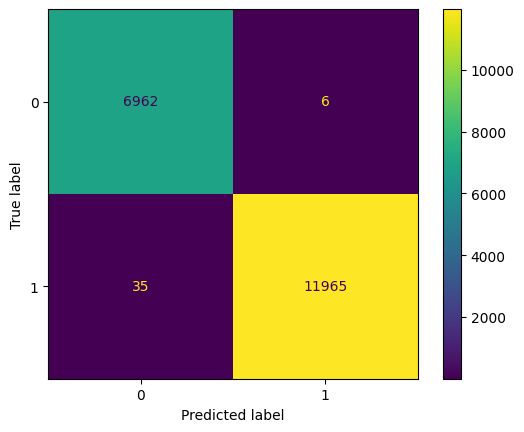

In [27]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

classNames=[0,1]
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob >= 0.5).astype(int)
y_pred = y_pred.ravel()
result = confusion_matrix(y_test_shape, y_pred)
print(result)

disp = ConfusionMatrixDisplay(confusion_matrix=result,display_labels=classNames)
disp.plot()
plt.show()